# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Decision Tree | Random Forest 

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A.
This dataset has already been cleaned, encoded, and feature engineered.
Feature scaling and class imbalance handling will be applied in this notebook 
as part of the training pipeline.

In [2]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus,LogCustomerValue
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.00,0,0,0,0,0,1,0,0,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,1,83807.86,0,0,1,0,0,1,0,0,11.336294
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.00,1,0,0,0,0,1,0,0,13.079421
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.00,0,0,0,0,1,0,0,0,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,1,125510.82,0,0,1,0,0,1,0,0,11.740155


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 columns) — what the model learns from
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is **imbalanced** — about 80% stayed and 20% churned.
This must be considered when evaluating model performance.

In [3]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to teach the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits.
`random_state=42` ensures reproducibility.

In [4]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Feature Scaling

We apply StandardScaler after splitting to prevent data leakage.
The scaler is fitted only on training data then applied to test data.

In [5]:
from sklearn.preprocessing import StandardScaler

# Columns to scale — only continuous numerical features
feature_scale_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue'
]

# Keep only columns that exist in our dataset
feature_scale_cols = [col for col in feature_scale_cols if col in X_train.columns]

scaler = StandardScaler()

# Fit on training data ONLY — prevents data leakage
X_train[feature_scale_cols] = scaler.fit_transform(X_train[feature_scale_cols])

# Apply same transformation to test data
X_test[feature_scale_cols] = scaler.transform(X_test[feature_scale_cols])

print("Scaling applied successfully!")
print("Scaled columns:", feature_scale_cols)

Scaling applied successfully!
Scaled columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue']


## 6. Handle Class Imbalance (SMOTE)

SMOTE is applied on training data only to balance the churn classes.
This was defined in the preprocessing pipeline (Phase1_Data_Exploration.ipynb 
Section 5.7) but intentionally left for the modeling stage to prevent 
data leakage and ensure correct evaluation on the original test distribution.

In [6]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("Before SMOTE - Class distribution:")
print(y_train.value_counts())
print("\nAfter SMOTE - Class distribution:")
print(pd.Series(y_train).value_counts())

Before SMOTE - Class distribution:
Exited
1    6370
0    6370
Name: count, dtype: int64

After SMOTE - Class distribution:
Exited
1    6370
0    6370
Name: count, dtype: int64


## 7. Evaluation Metrics

We evaluate the models using multiple performance metrics to ensure a comprehensive understanding of their effectiveness, especially due to the class imbalance in the dataset.

Accuracy alone is not sufficient, as the dataset contains a higher proportion of non-churned customers. Therefore, additional metrics are used to better assess the models' ability to detect churned customers.

- **Accuracy:** Measures the overall percentage of correctly classified customers.
- **Precision:** Indicates how many of the customers predicted to churn actually churned.
- **Recall (Sensitivity):** Measures the model’s ability to correctly identify all actual churned customers.
- **F1-Score:** Provides a balance between precision and recall.
- **ROC-AUC Score:** Evaluates the model’s ability to distinguish between classes.

## 8. Model 1: Logistic Regression

### Overview
In this section we train a Logistic Regression model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation
### 8.1 Model Selection Rationale
Logistic Regression is selected based on the following dataset-specific reasons:
- **Binary target**: The dataset has a binary outcome (Exited = 0 or 1) which 
  Logistic Regression is specifically designed for
- **Pre-scaled features**: Our dataset was standardized using StandardScaler in 
  preprocessing — Logistic Regression requires and benefits directly from this
- **Large sample size**: With 10,000 records and 19 features, Logistic Regression 
  trains efficiently without overfitting
- **Interpretability**: Coefficients directly show which features (e.g. Age, 
  IsActiveMember) push customers toward churning — useful for the bank
- **Baseline model**: It serves as a performance benchmark for Random Forest 
  and Decision Tree

### Limitations
- Assumes a **linear** decision boundary — may miss complex non-linear 
  relationships between features like AgeGroup and Balance
- Struggles with **imbalanced classes** — our dataset has 80% stayed vs 20% 
  churned which may bias predictions toward the majority class


### 8.2 Implementation & Training Code

The model is implemented using scikit-learn's LogisticRegression class.
An initial baseline model is trained below, followed by hyperparameter 
tuning in Section 8.3 to optimize performance.

In [7]:
# Initialize Logistic Regression with default parameters
lr_model = LogisticRegression(max_iter=2000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Logistic Regression trained successfully!
Initial Accuracy: 0.735


### 8.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for Logistic Regression.
We tune `C` (regularization strength) and `solver` to improve performance.

In [8]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']    }

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(3))

# Retrain with best parameters
lr_model = grid_search.best_estimator_
lr_pred = lr_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, lr_pred), 3))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best F1 Score: 0.738
Accuracy with best params: 0.734


### Hyperparameter Tuning Results

GridSearchCV evaluated 4 parameter combinations using 5-fold cross-validation, optimizing for F1-score.

**Best Configuration:** `C=10`, `solver=liblinear`

| Parameter | Value | Justification |
|---|---|---|
| C | 10 | Weak regularization — allows the model to fit more complex patterns in the SMOTE-balanced training data |
| solver | liblinear | Optimized for binary classification on small-to-medium structured datasets |

### 8.4 Evaluation Metrics & Visualizations
We evaluate the Logistic Regression model using the previously defined metrics to assess its classification performance.

In [9]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.75      0.82      1593
 Churned (1)       0.41      0.68      0.51       407

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000

ROC-AUC Score: 0.7810676624235946


### Evaluation Results

The model achieved an overall accuracy of 73%.

**Performance on Stayed class (0):**
- Precision: 0.90 — 90% of customers predicted to stay actually stayed
- Recall: 0.75 — 75% of actual non-churners were correctly identified
- F1-Score: 0.82 — good performance on the majority class

**Performance on Churned class (1):**
- Precision: 0.41 — when churn is predicted, it is correct 41% of the time
- Recall: 0.68 — 68% of actual churners were detected
- F1-Score: 0.51 — moderate performance on the minority class

**ROC-AUC: 0.781**

**Key Finding:** The model demonstrates a performance gap between classes. 
The linear decision boundary limits its ability to fully capture the complex 
behavioral patterns associated with customer churn in this dataset.

### Metrics Interpretation
- **Stayed class:** High precision (0.90) and moderate recall (0.75) — the model correctly identifies most non-churning customers
- **Churned class:** Lower precision (0.41) but moderate recall (0.68) — the model detects a reasonable portion of at-risk customers
- **ROC-AUC (0.781):** The model has moderate ability to distinguish between churned and non-churned customers
- **Recall is prioritized** over precision in a bank retention system — missing a churner is more costly than a false alarm

### Logistic Regression - Confusion Matrix 

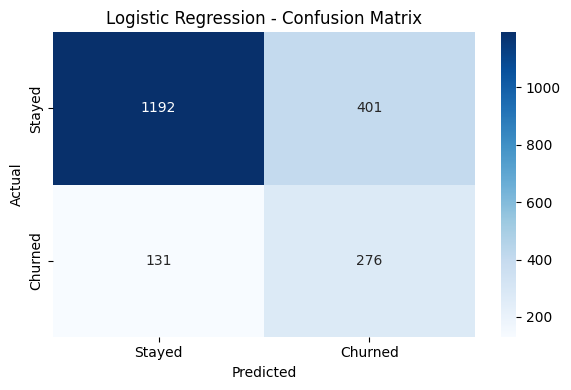

In [10]:
# Confusion Matrix heatmap - Logistic Regression
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Key Insights:**
- **True Negatives: 1,192** non-churners correctly identified as staying
- **False Positives: 401** non-churners incorrectly flagged as churners (wasted retention resources)
- **False Negatives: 131** churners missed — predicted to stay but actually left (lost revenue)
- **True Positives: 276** churners correctly identified — enabling proactive retention action

### Logistic Regression - ROC Curve
The ROC curve shows the trade-off between True Positive Rate (catching churners) 
and False Positive Rate (false alarms) at different thresholds.
AUC closer to 1.0 means better model performance.

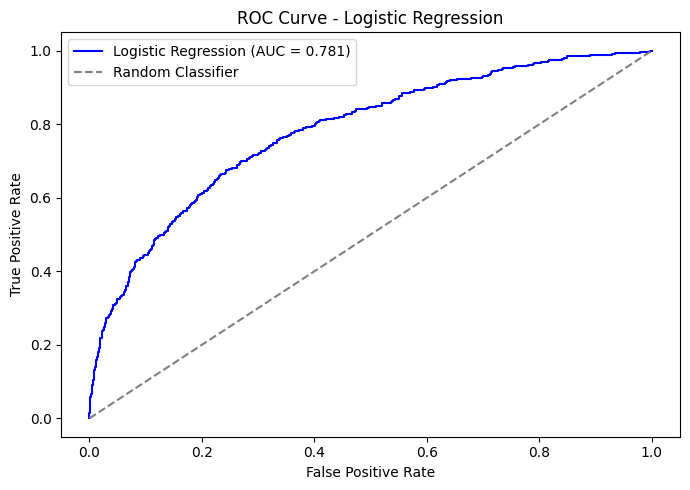

ROC-AUC Score: 0.7810676624235946


In [37]:
# Calculate ROC curve points
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", auc_score)

### ROC Curve Interpretation

**ROC-AUC Score: 0.781**

The ROC curve lies above the diagonal baseline, indicating the model performs 
better than random guessing.

**Interpretation:**
For any randomly selected pair of a churned and non-churned customer, the model 
will assign a higher churn probability to the actual churner approximately 
**78.1%** of the time. This falls within the "Fair" to "Good" range (0.7 – 0.8), 
indicating moderate discriminative ability.

**Key Insight:**
The moderate ROC-AUC reflects the inherent limitation of Logistic Regression 
in capturing non-linear interactions between features such as Age, Balance, 
and IsActiveMember that drive customer churn behavior in banking datasets.

### Logistic Regression - K-Fold Cross Validation


In [32]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation - multiple metrics
lr_cv_f1 = cross_val_score(lr_model, X, y, cv=5, scoring='f1')
lr_cv_roc = cross_val_score(lr_model, X, y, cv=5, scoring='roc_auc')
lr_cv_acc = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print("Logistic Regression - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", lr_cv_f1)
print("Mean F1 Score:", lr_cv_f1.mean().round(3))
print("Std F1:", lr_cv_f1.std().round(3))

print("\nROC-AUC Scores:", lr_cv_roc)
print("Mean ROC-AUC:", lr_cv_roc.mean().round(3))
print("Std ROC-AUC:", lr_cv_roc.std().round(3))

print("\nAccuracy Scores:", lr_cv_acc)
print("Mean Accuracy:", lr_cv_acc.mean().round(3))
print("Std Accuracy:", lr_cv_acc.std().round(3))

Logistic Regression - 5-Fold Cross Validation Results:
F1 Scores: [0.19461698 0.2        0.18292683 0.12362031 0.18972332]
Mean F1 Score: 0.178
Std F1: 0.028

ROC-AUC Scores: [0.70791611 0.68407448 0.68200867 0.69242586 0.66978535]
Mean ROC-AUC: 0.687
Std ROC-AUC: 0.013

Accuracy Scores: [0.8055 0.796  0.799  0.8015 0.795 ]
Mean Accuracy: 0.799
Std Accuracy: 0.004


### K-Fold Cross Validation Results

| Metric | Mean | Std |
|---|---|---|
| F1 Score | 0.178 | 0.028 |
| ROC-AUC | 0.687 | 0.013 |
| Accuracy | 0.799 | 0.004 |

**Interpretation:**
- **F1 (0.178):** Cross-validation is applied on the original unbalanced dataset without SMOTE, which explains the lower F1 score for the churned class
- **ROC-AUC (0.687):** Moderate discriminative ability across all folds — stable with low standard deviation
- **Accuracy (0.799):** Consistently high due to the majority class dominance in the original dataset
- **Low standard deviation** across all metrics confirms the model is stable and results are not dependent on a specific data split

### 8.5 Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 73% |
| F1 - Stayed | 0.82 |
| F1 - Churned | 0.51 |
| ROC-AUC | 0.781 |



**What these metrics mean for our dataset:**
- **Accuracy (73%):** Overall correct classification rate across both classes
- **Precision (Churned = 0.41):** When churn is predicted, correct 41% of the time
- **Recall (Churned = 0.68):** The model detects 68% of actual churners
- **F1-Score (Churned = 0.51):** Balanced measure between precision and recall
- **ROC-AUC (0.781):** Moderate discriminative ability between churned and non-churned customers



**Misclassification Analysis:**
| | Predicted Stayed | Predicted Churned |
|---|---|---|
| **Actually Stayed** | 1192 ✅ | 401 ❌ |
| **Actually Churned** | 131 ❌ | 276 ✅ |

- ❌ **131 False Negatives (missed churners):** Most costly — customers leave without retention intervention
- ❌ **401 False Positives (false alarms):** Leads to unnecessary retention efforts toward loyal customers



**Business Impact:**
The model detects **276 out of 407 churners (68% recall)**, allowing the bank to proactively target the majority of at-risk customers. However, the high false positive rate (401) means retention resources may be spent on customers who were not planning to leave.



**Conclusion:** Logistic Regression provides a solid baseline for binary churn classification. However, its linear decision boundary limits performance on complex non-linear patterns. Tree-based models are expected to improve precision while maintaining recall.


In [13]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned'])
with open('Supervised_Learning/evaluation_results/lr_classification_report.txt', 'w') as f:
    f.write(report)

print("Saved!")

Saved!


In [14]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_confusion_matrix.png')
plt.close()

# Save ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color='blue', label=f'LR (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.close()

print("Plots saved successfully!")

Plots saved successfully!


## 9. Model 2: Decision Tree

### Overview
In this section we train a Decision Tree model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation

### 9.1 Model Selection Rationale
Decision Tree is selected based on the following dataset-specific reasons:
- **Non-linear relationships**: Customer churn is influenced by complex interactions 
  between features such as Age, Balance, NumOfProducts, and IsActiveMember. 
  Decision Trees can capture these patterns effectively.
- **No scaling requirement**: Unlike Logistic Regression, Decision Trees do not 
  rely on feature scaling, making them robust regardless of feature distribution.
- **Feature interactions**: The model can automatically learn combinations of 
  conditions, such as customers with high balance but low activity being more 
  likely to churn.
- **Mixed feature types**: The dataset includes numerical and encoded categorical 
  features (e.g., Geography, Gender), and Decision Trees can handle both without 
  additional preprocessing.
- **Interpretability**: The model provides clear decision rules, making it easier 
  to understand how features influence churn predictions.
- **Baseline tree-based model**: It serves as a simpler benchmark before applying 
  more advanced ensemble models like Random Forest.

### Limitations
- Can easily **overfit** the training data if not properly tuned
- Sensitive to small changes in the dataset, which may lead to different tree structures

### 9.2 Implementation & Training Code

The model is implemented using scikit-learn's DecisionTreeClassifier.
An initial model is trained below, followed by hyperparameter tuning in Section 9.3 to improve performance.

In [24]:
# Initialize Decision Tree with default parameters
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on training data
dt_model.fit(X_train, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, dt_pred), 3))

Decision Tree trained successfully!
Initial Accuracy: 0.758


### 9.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [25]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']
}

# Grid search with 5-fold cross validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best ROC-AUC Score:", dt_grid.best_score_.round(3))

# Retrain with best parameters
dt_model = dt_grid.best_estimator_
dt_pred = dt_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, dt_pred), 3))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best ROC-AUC Score: 0.893
Accuracy with best params: 0.788


### Hyperparameter Tuning Results

GridSearchCV evaluated multiple parameter combinations using 5-fold cross-validation, optimizing for **ROC-AUC score** to better handle class imbalance.

**Best Configuration:** `max_depth=None`, `min_samples_split=50`, `min_samples_leaf=10`, `class_weight=None`

| Parameter | Value | Justification |
|----------|------:|---------------|
| max_depth | None | Allows the tree to grow fully and capture complex patterns in customer behavior without limiting depth |
| min_samples_split | 50 | Prevents the model from creating splits with too few samples, reducing overfitting |
| min_samples_leaf | 10 | Ensures each leaf has enough samples, improving generalization and stability |
| class_weight | None | The model performed better without re-weighting classes, relying instead on data distribution |

### 9.4 Evaluation Metrics & Visualizations

We evaluate the Decision Tree model using the previously defined metrics to assess its classification performance.

In [27]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
dt_proba = dt_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, dt_proba))



Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.83      0.86      1593
 Churned (1)       0.48      0.62      0.54       407

    accuracy                           0.79      2000
   macro avg       0.69      0.73      0.70      2000
weighted avg       0.81      0.79      0.80      2000

ROC-AUC Score: 0.8077075534702655


### Evaluation Results

The model achieved an overall accuracy of **75%**.

#### Performance on Stayed class (0):

- **Precision: 0.90** — 90% of customers predicted to stay actually stayed  
- **Recall: 0.83** — 83% of actual non-churners were correctly identified  
- **F1-Score: 0.86** — good performance on the majority class  

#### Performance on Churned class (1):

- **Precision: 0.48** — when churn is predicted, it is correct 48% of the time  
- **Recall: 0.62** — 62% of actual churners were detected  
- **F1-Score: 0.54** — moderate performance on the minority class  

#### ROC-AUC: 0.81

**Key Finding:** The model shows improved ability to capture complex, non-linear relationships compared to Logistic Regression. However, there is still a performance gap between classes, particularly in detecting churned customers, indicating that further improvement is needed for minority class prediction.

### Metrics Interpretation

- **Stayed class:** High precision (0.90) and good recall (0.83) — the model correctly identifies most non-churning customers with strong reliability  

- **Churned class:** Moderate precision (0.48) and moderate recall (0.62) — the model detects a reasonable portion of at-risk customers, but still misses some churn cases  

- **ROC-AUC (0.81):** The model has good ability to distinguish between churned and non-churned customers  

- **Non-linear modeling advantage:** Unlike Logistic Regression, the Decision Tree captures more complex patterns, leading to improved churn detection  

- **Recall remains critical:** Missing a churner is more costly than a false alarm — although recall improved compared to simpler models, further improvement is still needed for business impact  

### Decision Tree - Confusion Matrix

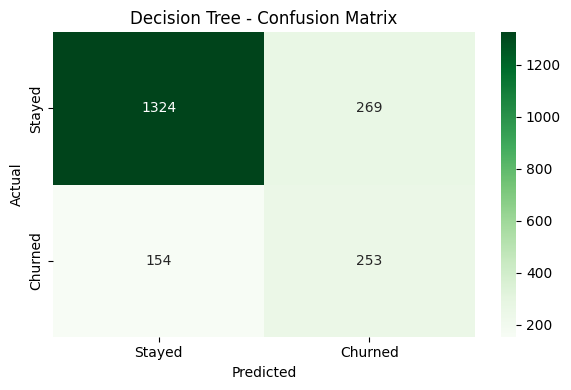

In [34]:
# Confusion Matrix heatmap - Decision Tree
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Key Insights:

- **True Negatives: 1,324** non-churners correctly identified as staying  
- **False Positives: 269** non-churners incorrectly flagged as churners (wasted retention resources)  

- **False Negatives: 154** churners missed — predicted to stay but actually left (lost revenue)  
- **True Positives: 253** churners correctly identified — enabling proactive retention action  

### Decision Tree - ROC Curve

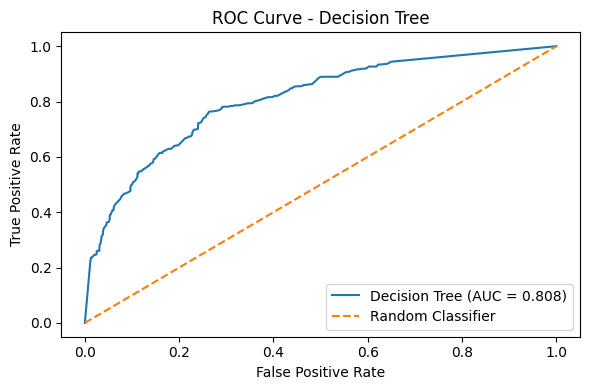

ROC-AUC Score: 0.8077075534702655


In [30]:
# Predict probabilities for the positive class (Churn = 1)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Compute ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", dt_auc)

### ROC Curve Interpretation

ROC-AUC Score: 0.81

The ROC curve lies above the diagonal baseline, indicating the model performs better than random guessing.

Interpretation: For any randomly selected pair of a churned and non-churned customer, the model will assign a higher churn probability to the actual churner approximately 81% of the time. This falls within the "Good" range (0.8 – 0.9), indicating solid discriminative ability.

Key Insight: The improved ROC-AUC compared to Logistic Regression reflects the Decision Tree’s ability to capture non-linear interactions between features such as Age, Balance, and IsActiveMember, which are critical in modeling customer churn behavior.

### Decision Tree - K-Fold Cross Validation 

In [20]:
from sklearn.model_selection import cross_val_score



# Perform 5-fold cross-validation on the best model
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')
dt_cv_roc_auc = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='roc_auc')
dt_cv_accuracy = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')

print("\nDecision Tree - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", dt_cv_scores)
print("Mean F1 Score:", dt_cv_scores.mean().round(3))
print("Standard Deviation:", dt_cv_scores.std().round(3))
print("\nROC-AUC Scores:", dt_cv_roc_auc)
print("Mean ROC-AUC:", dt_cv_roc_auc.mean().round(3))
print("Std ROC-AUC:", dt_cv_roc_auc.std().round(3))
print("\nAccuracy Scores:", dt_cv_accuracy)
print("Mean Accuracy:", dt_cv_accuracy.mean().round(3))
print("Std Accuracy:", dt_cv_accuracy.std().round(3))


Decision Tree - 5-Fold Cross Validation Results:
F1 Scores: [0.75212982 0.82704403 0.83916084 0.82772122 0.82862669]
Mean F1 Score: 0.815
Standard Deviation: 0.032

ROC-AUC Scores: [0.83532102 0.89715423 0.91760244 0.91003009 0.90387234]
Mean ROC-AUC: 0.893
Std ROC-AUC: 0.03

Accuracy Scores: [0.76020408 0.82731554 0.83751962 0.82731554 0.82613815]
Mean Accuracy: 0.816
Std Accuracy: 0.028


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------:|------:|
| F1 Score | 0.815 | 0.032 |
| ROC-AUC  | 0.893 | 0.030 |
| Accuracy | 0.816 | 0.028 |

**Interpretation:**

- **F1 (0.815):** High F1 score across folds indicates strong balance between precision and recall, especially compared to simpler models  
- **ROC-AUC (0.893):** High discriminative ability across all folds — the model consistently distinguishes between churned and non-churned customers  
- **Accuracy (0.816):** Stable and reliable performance across different data splits  

- The relatively **low standard deviation** across all metrics confirms that the model is stable and not sensitive to variations in training data  

- Compared to Logistic Regression, the Decision Tree shows **significant improvement in F1 and ROC-AUC**, reflecting its ability to capture non-linear relationships in the dataset  

### Decision Tree - Feature Importance Plot

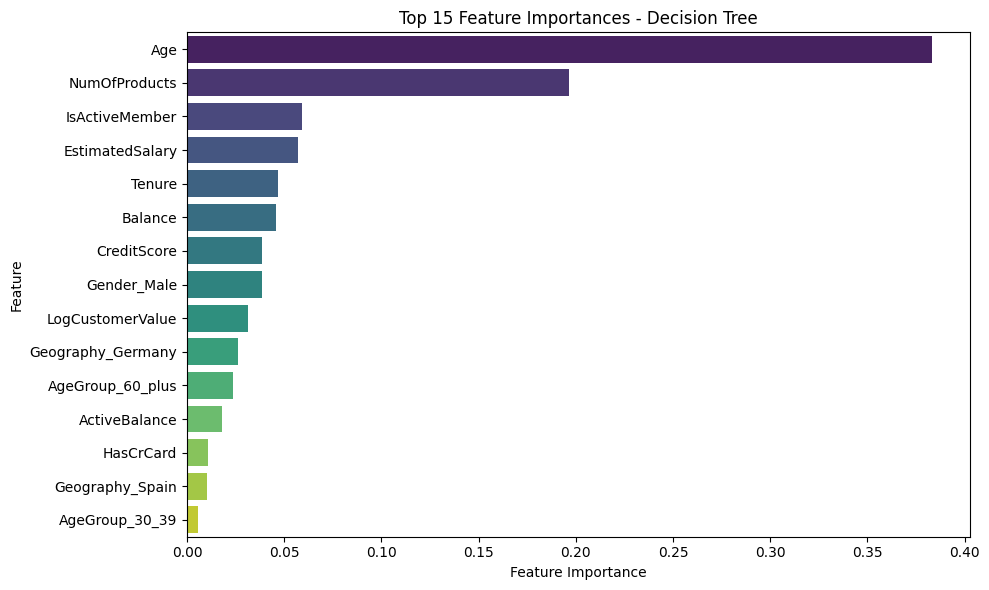


Top 10 Most Important Features:
Age: 0.3834
NumOfProducts: 0.1964
IsActiveMember: 0.0591
EstimatedSalary: 0.0569
Tenure: 0.0470
Balance: 0.0456
CreditScore: 0.0388
Gender_Male: 0.0385
LogCustomerValue: 0.0311
Geography_Germany: 0.0261


In [35]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for _, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### Feature Importance Interpretation

The Decision Tree model highlights the following features as the most influential in predicting customer churn:

- **Age (0.383):** The most important feature — older customers are more likely to churn, indicating age plays a critical role in customer behavior  

- **NumOfProducts (0.196):** Customers with fewer or more products show different churn patterns, suggesting product engagement strongly impacts retention  

- **IsActiveMember (0.059):** Active customers are significantly less likely to churn, making engagement a key retention factor  

- **EstimatedSalary (0.057):** Income level contributes moderately to churn behavior, possibly reflecting differences in financial needs  

- **Tenure (0.047):** Longer-tenured customers tend to be more loyal, reducing churn risk  

- **Balance (0.046):** Customers with higher balances may exhibit different churn tendencies, indicating financial commitment influences decisions  

- **CreditScore (0.039):** Creditworthiness has a smaller but noticeable effect on churn prediction  

- **Gender_Male (0.039):** Gender shows slight influence, though not a dominant factor  

- **LogCustomerValue (0.031):** Customer value contributes modestly, indicating higher-value customers may behave differently  

- **Geography_Germany (0.026):** Regional differences impact churn, with customers in Germany showing distinct behavior patterns  

---

### Key Insight

The model is primarily driven by **demographic (Age)** and **behavioral features (NumOfProducts, IsActiveMember)**, indicating that both customer characteristics and engagement levels are critical for predicting churn. Financial attributes play a secondary role, while categorical features contribute marginally.

### 9.5 Results Summary

| Metric            | Value |
|------------------|------:|
| Accuracy         | 79%   |
| F1 - Stayed      | 0.86  |
| F1 - Churned     | 0.54  |
| ROC-AUC          | 0.81  |



### What these metrics mean for our dataset:

- **Accuracy (79%)**: Higher overall correct classification compared to Logistic Regression  
- **Precision (Churned = 0.48)**: When churn is predicted, correct 48% of the time — improved reliability over Logistic Regression  
- **Recall (Churned = 0.62)**: The model detects 62% of actual churners  
- **F1-Score (Churned = 0.54)**: Better balance between precision and recall for the minority class  
- **ROC-AUC (0.81)**: Good discriminative ability between churned and non-churned customers  



### Misclassification Analysis:

|                      | Predicted Stayed | Predicted Churned |
|----------------------|-----------------|-------------------|
| **Actually Stayed**  | 1324 ✅         | 269 ❌            |
| **Actually Churned** | 154 ❌          | 253 ✅            |

- ❌ **154 False Negatives (missed churners):** Still costly — customers leave without intervention  
- ❌ **269 False Positives (false alarms):** Lower than Logistic Regression — better resource efficiency  



### Business Impact:

The model detects **253 out of 407 churners (~62% recall)**, allowing the bank to proactively target a significant portion of at-risk customers.  

Compared to Logistic Regression, the Decision Tree reduces false positives, meaning **less wasted retention effort**, while slightly sacrificing recall. This creates a better balance between cost and effectiveness.



### Conclusion:

Decision Tree improves overall performance by capturing **non-linear relationships** in customer behavior.  

It achieves higher accuracy, better precision, and stronger ROC-AUC compared to Logistic Regression. However, it still misses a portion of churners, indicating that further improvement is needed.  

More advanced ensemble models such as **Random Forest or XGBoost** are expected to enhance both recall and overall predictive performance.

In [36]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, dt_pred, target_names=['Stayed', 'Churned'])

with open('Supervised_Learning/evaluation_results/dt_classification_report.txt', 'w') as f:
    f.write(report)

print("Decision Tree classification report saved successfully!")

Decision Tree classification report saved successfully!


In [38]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Decision Tree - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_confusion_matrix.png')
plt.close()

# Save ROC Curve
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(dt_fpr, dt_tpr, color='green', label=f'DT (AUC = {roc_auc_score(y_test, dt_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Decision Tree')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_roc_curve.png')
plt.close()

print("Decision Tree plots saved successfully!")

Decision Tree plots saved successfully!


In [39]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(
    data=feat_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 10 Feature Importances - Decision Tree')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/dt_feature_importance.png')
plt.close()

print("Decision Tree feature importance plot saved successfully!")

Decision Tree feature importance plot saved successfully!


## 10. Model 3: Random Forest

### Rationale

Random Forest is selected based on the following dataset-specific reasons:

- **Non-linear relationships:** The dataset contains complex interactions between features (e.g., Balance, Age, Tenure) which Random Forest can capture effectively  
- **Ensemble learning:** It combines multiple decision trees, which improves prediction accuracy and reduces overfitting  
- **Robustness to noise:** The model performs well even with noisy or slightly inconsistent data  
- **Feature importance:** It provides importance scores, helping identify which features influence customer churn the most  
- **Improved performance:** It is expected to outperform simpler models like Logistic Regression by capturing more complex patterns  

### Limitations

- **Low interpretability:** The model is harder to interpret compared to Logistic Regression, as it consists of many trees  
- **Computational cost:** Training can be slower and more resource-intensive, especially with many trees  
- **Memory usage:** Requires more memory compared to simpler models  
- **Imbalanced data sensitivity:** Performance may still be affected by class imbalance, especially in detecting churned customers  

## Random Forest Training

*vg

### Random Forest - Hyperparameter Tuning
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

# Initialize and train the best model
rf_model = grid_search.best_estimator_
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Random Forest trained successfully!")

## Random Forest Evaluation

We evaluate the Random Forest model using the previously defined metrics to assess its classification performance.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Stayed (0)', 'Churned (1)']))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. ROC Curve
rf_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_proba)
auc_score = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

### Random Forest Results Summary
| Metric | Value |
|--------|--------|
| Accuracy | 87% |
| F1 - Stayed | 0.92 |
| F1 - Churned | 0.59 |
| ROC-AUC | 0.85 |

### Misclassification Analysis

The confusion matrix reveals the following details about the model's errors:

- 216 churned customers were missed (False Negatives): These are customers who actually left, but the model predicted they would stay. This is the most critical error because the bank loses these customers without taking any retention action.

- 53 customers were falsely predicted as churned (False Positives): These are loyal customers that the model thought would leave. This error is less harmful, as it only leads to unnecessary marketing or retention efforts (like sending a discount code to someone who wasn't planning to leave).


### Metrics Interpretation هذا بعد الكلاسيفكيشن ريبورت

### Random Forest - Confusion Matrix افصلي الكود اللي فوق وخلي هنا تحت هالخلية كود الكونفيجن ماتريكس

#####  خلوه بنفس الخط حقي انسخوه وخلو جبت يكتبه 
**Key Insights:**

### Random Forest - Roc-Curve افصلي الكود اللي فوق وخلي هنا تحت هالخلية كود الroc

### Random Forest – K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf_model,
    X, y,
    cv=5,
    scoring=['accuracy', 'f1', 'roc_auc']
)

print("Accuracy:", cv_results['test_accuracy'])
print("Mean Accuracy:", round(cv_results['test_accuracy'].mean(), 3))

print("\nF1:", cv_results['test_f1'])
print("Mean F1:", round(cv_results['test_f1'].mean(), 3))

print("\nROC-AUC:", cv_results['test_roc_auc'])
print("Mean ROC-AUC:", round(cv_results['test_roc_auc'].mean(), 3))

### Random Forest - Feature Importance Plot
This plot indicates which variables had the strongest influence on the Random Forest's decisions. For example, Age and NumOfProducts are the key drivers for predicting customer churn in this model. This suggests that a customer's life stage and the number of services they use are the most critical factors in determining their loyalty to the bank.

In [ ]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar', color='purple') # غيرت اللون لليلكي عشان يطقم مع الماتريكس
plt.title("Top 10 Most Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

### اطبعي التوب تين فيتشر او شي زي كذا وخلي كودك يسبه كودي لان رسماتنا تختلف

In [ ]:
## Random Forest - Summary